<a href="https://colab.research.google.com/github/mahigarg0403-blip/Customer-purchase-prediction_mahi_bhumika/blob/main/notebooks/%20step6_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
#cell 1 : import drive
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

import os
path = '/content/drive/MyDrive/CPP-ML PROJECT-BHUMIKA-MAHI/'
print(os.listdir(path))

Mounted at /content/drive
['plot1_class_distribution.png', 'plot2_numerical_distributions.png', 'plot3_categorical_distributions.png', 'plot4_bivariate_categorical.png', 'plot5_boxplots.png', 'plot6_correlation_heatmap.png', 'plot7_outliers.png', 'step2', 'cleaned_data.csv', 'step 4', 'logistic_regression.pkl', 'lr_confusion_matrix.png', 'lr_roc_curve.png', 'lr_coefficients.png', 'lr_results.csv']


In [37]:
#cell 2 : importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, roc_curve, classification_report)

In [38]:
#cell 2 :importing datasets
path = '/content/drive/MyDrive/CPP-ML PROJECT-BHUMIKA-MAHI/step 4/'

x_train = pd.read_csv(path + 'x_train_tree_final.csv')
x_test = pd.read_csv(path + 'x_test_tree_final.csv')
y_train = pd.read_csv(path + 'y_train_tree_final.csv').values.ravel()
y_test = pd.read_csv(path + 'y_test_tree_final.csv').values.ravel()

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train distribution:", pd.Series(y_train).value_counts().to_dict())
print("y_test distribution:", pd.Series(y_test).value_counts().to_dict())

x_train shape: (16476, 21)
x_test shape: (2441, 21)
y_train distribution: {1: 8238, 0: 8238}
y_test distribution: {0: 2059, 1: 382}


In [39]:
#cell 3 : training the model

rf_base = RandomForestClassifier(random_state = 42)

param_grid = { 'n_estimators' : [100,200,500], 'max_depth' : [5, 10, None]}

grid_search = GridSearchCV(
    estimator = rf_base,
    param_grid = param_grid,
    scoring = 'f1',
    cv = 5,
    n_jobs = 1
)

grid_search.fit(x_train, y_train)
rf_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print(best_params)
print(grid_search.best_score_)

{'max_depth': None, 'n_estimators': 200}
0.9309135715159943


In [41]:
#cell 4 : testing the model

y_pred = rf_model.predict(x_test)
y_prob = rf_model.predict_proba(x_test)[:,1] #for roc curve

In [42]:
#cell 5 : scores
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test,y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test,y_pred)
auc = roc_auc_score(y_test,y_pred)

print('-'*30)
print("Random Forest Results")
print('-'*30)
print(f"Accuracy : {accuracy:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"AUC Score : {auc:.4f}")
print(classification_report(y_test,y_pred))

------------------------------
Random Forest Results
------------------------------
Accuracy : 0.8865
F1 Score : 0.6768
Precision : 0.6105
Recall : 0.7592
AUC Score : 0.8347
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      2059
           1       0.61      0.76      0.68       382

    accuracy                           0.89      2441
   macro avg       0.78      0.83      0.80      2441
weighted avg       0.90      0.89      0.89      2441



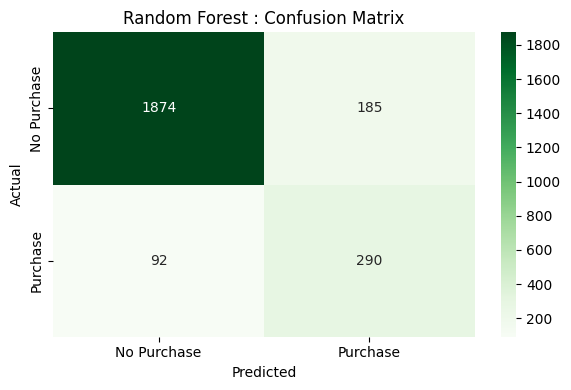

In [43]:
#cell 5 : confusion matrix

cfm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cfm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'])
plt.title('Random Forest : Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150)
plt.show()

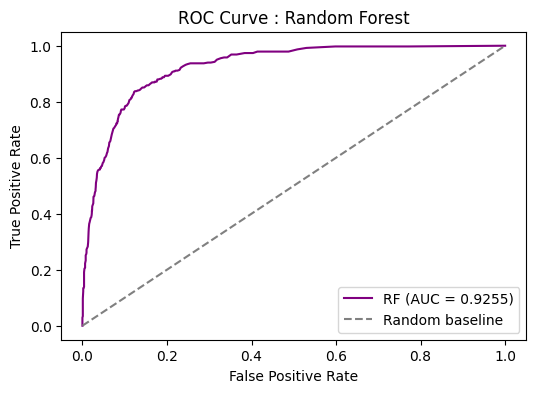

In [44]:
#cell 6 : AUC ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'RF (AUC = {auc_score:.4f})', color='purple')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve : Random Forest')
plt.legend()
plt.savefig('rf_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1666/4123426676.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances.head(15), palette='coolwarm')


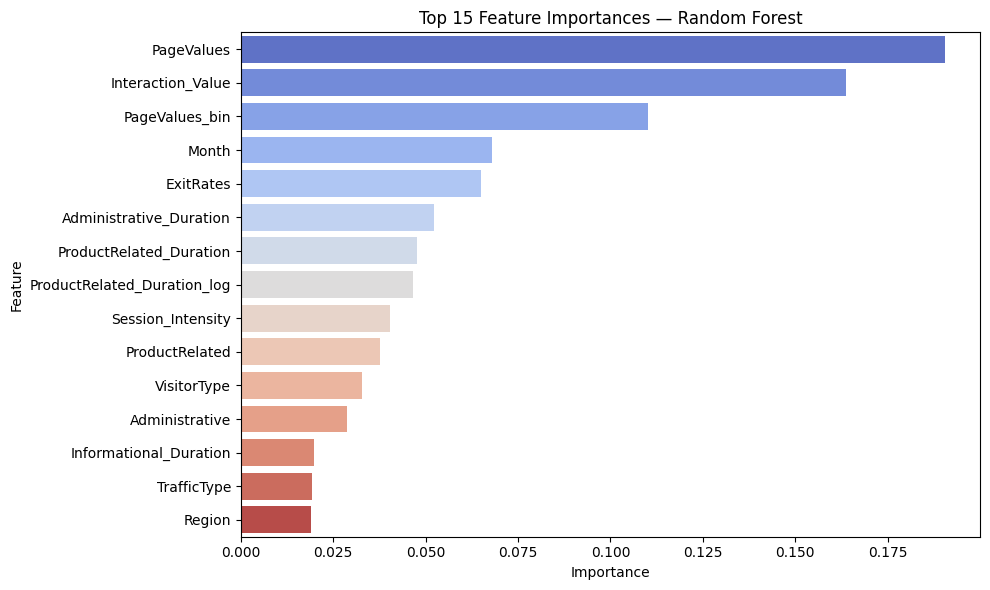

In [45]:
#cell 7 : Feature Importance Bar graph

importances = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importances.head(15), palette='coolwarm')
plt.title('Top 15 Feature Importances — Random Forest')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()

In [50]:
#cell 8 : Saving random forest results
rf_results = pd.DataFrame({
    'Model': 'Random Forest',
    'Accuracy' : f'{accuracy:.4f}',
    'F1': f'{f1:.4f}',
    'Precision': f'{precision:.4f}',
    'Recall': f'{recall:.4f}',
    'AUC': f'{auc:.4f}',
    'Best_n_estimators': [best_params['n_estimators']],
    'Best_max_depth': [best_params['max_depth']]
})
rf_results.to_csv('rf_results.csv', index=False)
rf_results

,Model,Accuracy,F1,Precision,Recall,AUC,Best_n_estimators,Best_max_depth
0,Random Forest,0.8865,0.6768,0.6105,0.7592,0.8347,200,None


In [49]:
#cell 9 : saving plots and model
path = '/content/drive/MyDrive/CPP-ML PROJECT-BHUMIKA-MAHI/'

# Save model
joblib.dump(rf_model, 'random_forest.pkl')
shutil.copy('random_forest.pkl', path + 'random_forest.pkl')

# Save plots and result
for plot in ['rf_confusion_matrix.png', 'rf_roc_curve.png', 'rf_feature_importance.png','rf_results.csv']:
    shutil.copy(plot, path + plot)

print("Saved!")

Saved!
